In [96]:
import numpy as np

from indpensim.driver import BatchConfig, CampaignConfig, batch_spec_from_python_rng
from indpensim.recipe import legacy_sbc_recipe
from indpensim.simulation import simulate_iter
import pandas as pd

In [97]:
rng = np.random.default_rng(42)
spec = batch_spec_from_python_rng(
    rng, batch_no=1,
    campaign=CampaignConfig(),   # optimum_T=10 - short batch: 50 samples
    batch=BatchConfig(recipe=legacy_sbc_recipe()),
)


In [98]:
stream = simulate_iter(spec)
print(f"control handle: {type(stream.control).__name__}")


control handle: RecipeExecutor


In [99]:
samples = []
t_sp = None
while True:
  try:
      sample = stream.next()
  except StopIteration:
      break
  samples.append(sample)

  if t_sp is None:
      t_sp = sample.state["T"]      # seed once, from the actual starting temperature
  else:
      t_sp -= 0.5                   # ramp down 0.5 K every step after that
      stream.control.set_setpoint("T_sp", t_sp)

In [100]:
df = pd.DataFrame([
      {"k": s.k, "sim_time_h": s.sim_time_h, "phase": s.phase, "phase_state": s.phase_state,
       **s.state, **s.controls}
      for s in samples
  ]).set_index("k")

In [101]:
df

,sim_time_h,phase,phase_state,S,DO2,O2,P,V,Wt,pH,...,Fa,Fb,Fc,Fh,Fw,pressure,viscosity,Fremoved,Fpaa,Foil
k,,,,,,,,,,,,,,,,,,,,,
1,0.2,INOCULATE,RUNNING,1.145728,14.737996,0.194442,0.001000,58061.351693,61843.786843,6.565318,...,0.0,0.000000,0.000100,122.220806,0.0,0.6,4.0,-0.0,5.0,22.0
2,0.4,INOCULATE,RUNNING,1.196040,14.715475,0.203695,0.001000,58058.709254,61845.623779,6.543848,...,0.0,0.000000,0.000100,40.320472,0.0,0.6,4.0,-0.0,5.0,22.0
3,0.6,INOCULATE,RUNNING,1.245395,14.698548,0.205806,0.000999,58056.062652,61847.464697,6.523409,...,0.0,0.000000,59.221998,4.032047,0.0,0.6,4.0,-0.0,5.0,22.0
4,0.8,INOCULATE,RUNNING,1.293784,14.692618,0.206288,0.000999,58053.444717,61849.341626,6.503903,...,0.0,0.000000,70.659496,0.403205,0.0,0.6,4.0,-0.0,5.0,22.0
5,1.0,INOCULATE,RUNNING,1.340483,14.679059,0.206318,0.000998,58050.862719,61851.254484,6.485165,...,0.0,0.000000,89.009860,0.040320,0.0,0.6,4.0,-0.0,5.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1146,229.2,PRODUCTION,RUNNING,100.347327,15.217264,0.201004,3.801087,78568.148261,88741.754029,6.505082,...,0.0,10.658897,1500.000000,0.000100,250.0,0.9,4.0,-0.0,4.0,23.0
1147,229.4,PRODUCTION,RUNNING,100.421416,15.214401,0.200967,3.797302,78634.669100,88817.479235,6.503297,...,0.0,9.153252,1500.000000,0.000100,250.0,0.9,4.0,-0.0,4.0,23.0
1148,229.6,PRODUCTION,RUNNING,100.497658,15.215980,0.200957,3.793524,78700.979033,88893.082420,6.500559,...,0.0,8.358780,1500.000000,0.000100,250.0,0.9,4.0,-0.0,4.0,23.0


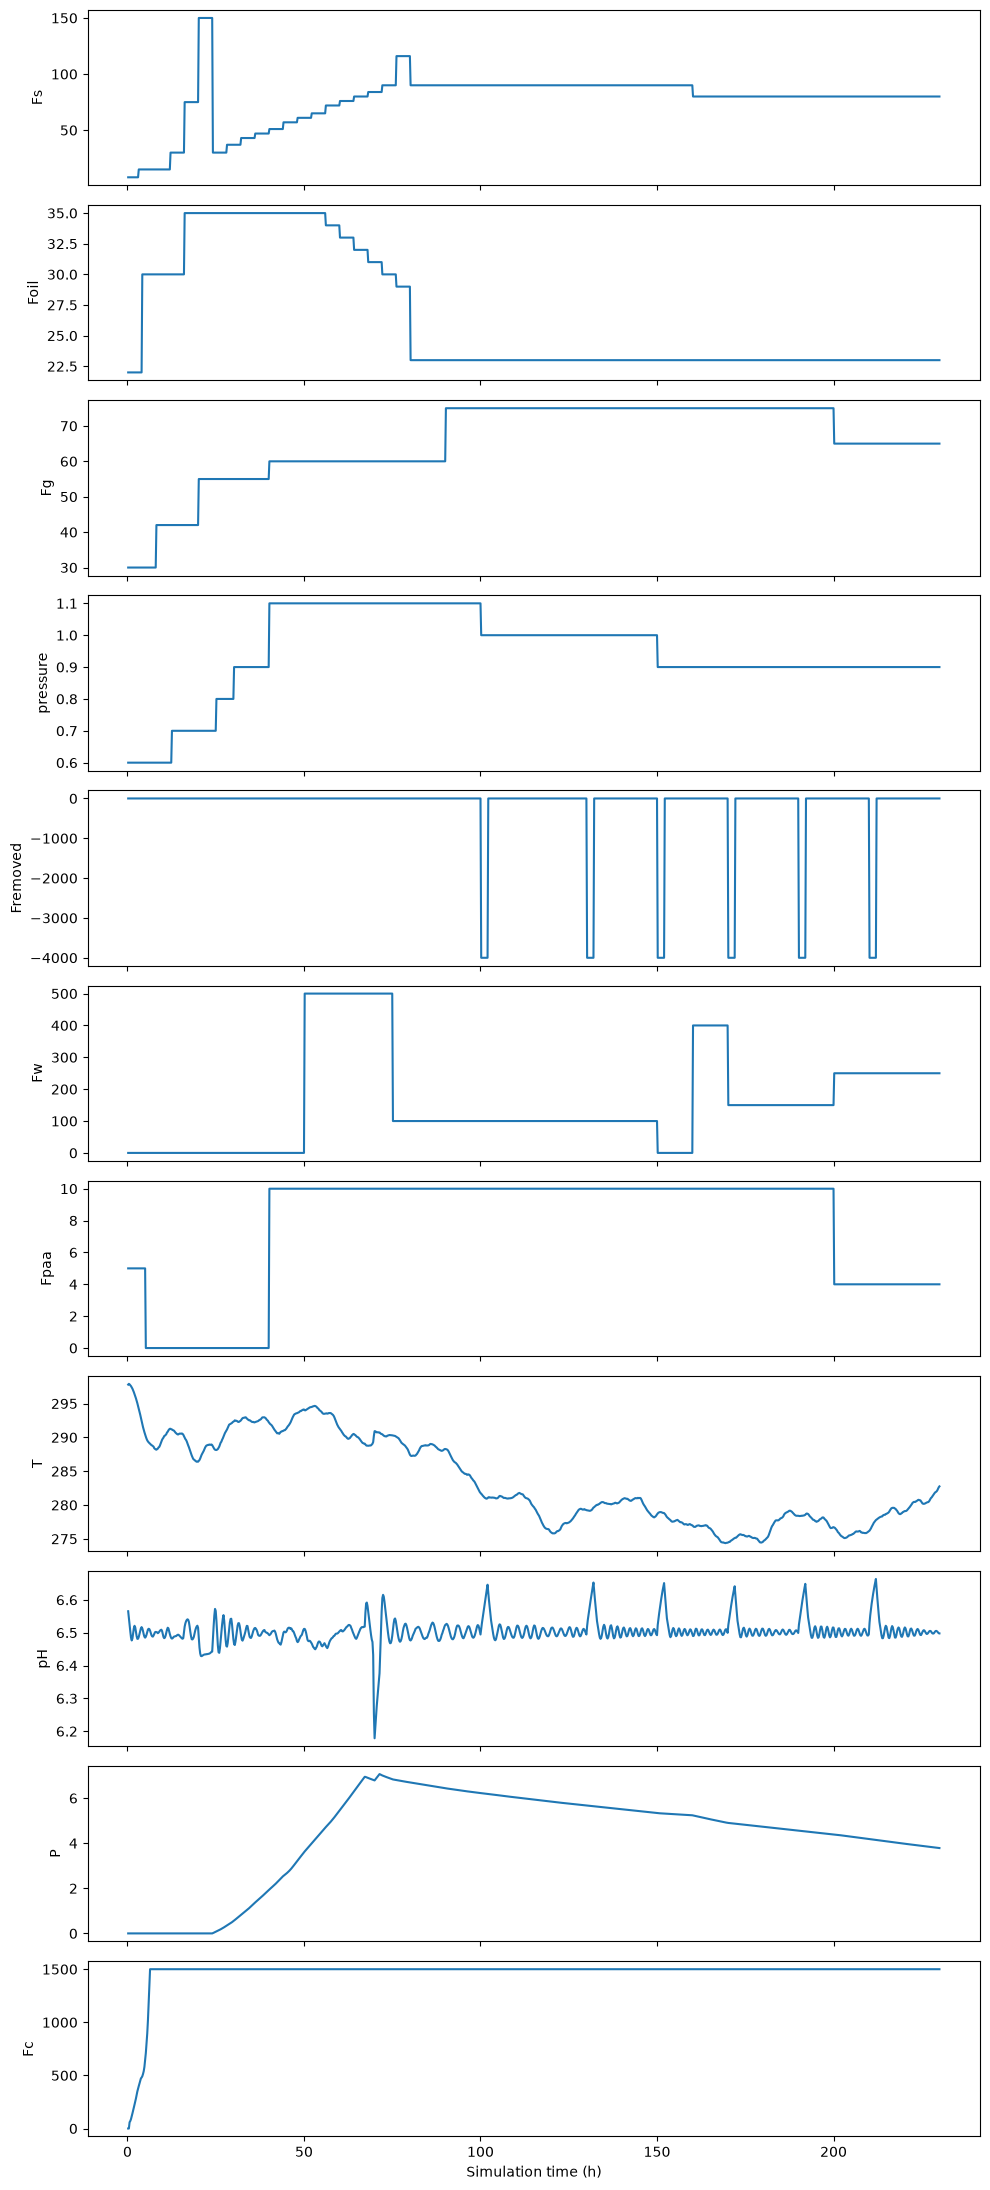

In [104]:
from matplotlib import pyplot as plt

channels = ["Fs", "Foil", "Fg", "pressure", "Fremoved", "Fw", "Fpaa", "T", "pH", "P", "Fc"]

fig, axes = plt.subplots(len(channels), 1, figsize=(10, 2.0*len(channels)), sharex=True)
for ax, ch in zip(axes, channels):
  ax.plot(df["sim_time_h"], df[ch])
  ax.set_ylabel(ch)
axes[-1].set_xlabel("Simulation time (h)")
plt.tight_layout()
plt.show()
